# 1. Data Preparation

## Theory

Quadratic Regression is a supervised machine learning technique used to model nonlinear relationships between an independent variable x and a dependent variable y. Unlike linear regression, which fits a straight line, quadratic regression fits a parabolic curve represented by:

y=ax^2
+bx+c

where:

a = coefficient of the quadratic term
b = coefficient of the linear term
c = bias/intercept

In this experiment, PyTorch is used to build a custom regression model. The model parameters are defined using nn.Parameter, allowing PyTorch's automatic differentiation system (Autograd) to compute gradients during training.

The dataset is divided into training and testing sets. The model predictions are compared with actual values using the Mean Absolute Error (MAE) loss function (nn.L1Loss). The optimizer used is Stochastic Gradient Descent (SGD), which updates the model parameters iteratively to minimize prediction error.

The training process consists of:

Forward propagation to generate predictions.
Loss computation.
Backpropagation to calculate gradients.
Parameter updates using SGD.
Repeating the process for multiple epochs until the loss converges.

In [146]:
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [148]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [149]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [150]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

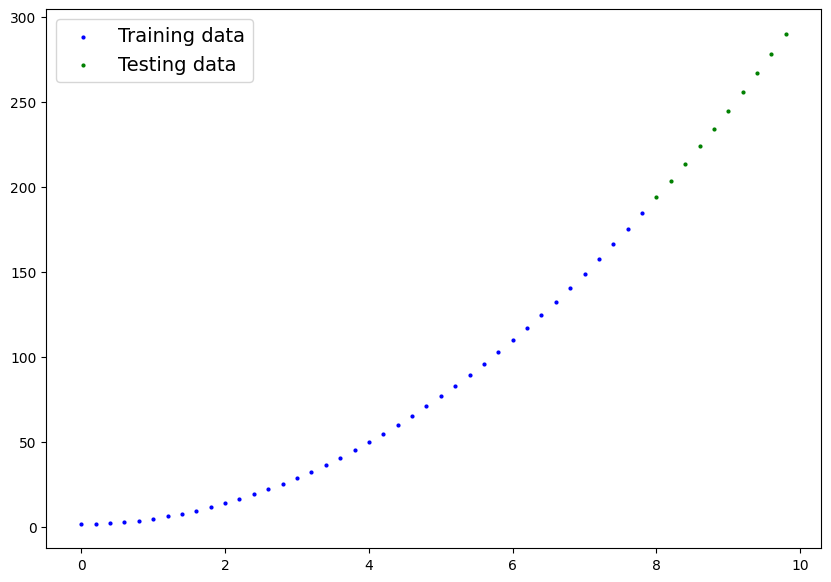

In [151]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

Now we've got some data, let's build a model to use the blue dots to predict the green dots.

We're going to jump right in.

We'll write the code first and then explain everything.

Let's replicate a standard linear regression model using pure PyTorch.

In [152]:
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        
        # Weight for the x^2 term (a)
        self.weight_quad = nn.Parameter(torch.randn(1, 
                                        dtype=torch.float), 
                                        requires_grad=True)
        
        # Weight for the x term (b)
        self.weight_linear = nn.Parameter(torch.randn(1, 
                                          dtype=torch.float), 
                                          requires_grad=True)
        self.weights=[self.weight_linear,self.weight_quad]
        # Bias term (c)
        self.bias = nn.Parameter(torch.randn(1, 
                                 dtype=torch.float), 
                                 requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # This is the quadratic formula: y = a*(x^2) + b*x + c
        return self.weight_quad * (x ** 2) + self.weight_linear * x + self.bias

**Pytorch Model building Essentials**

- `torch.nn` : collection of neural-network components (layers, activations, losses) used to build models.
- `torch.nn.Parameter` : a tensor wrapper for model parameters; when requires_grad=True it’s tracked for gradient-based updates.
- `torch.nn.Module` : base class for models/layers; create your network by subclassing it and using its utilities.
- `torch.optim` : optimization algorithms (SGD, Adam, etc.) that update Parameters using gradients.
- `def forward()` : the method you implement in an nn.Module that defines the layer/model’s forward computation on input data.

![Model in Pytorch](../../Old_Syllabus/Lab3-NN/images/linear_regression_model_pytorch.png)

- [Pytorch Cheat Sheet](https://pytorch.org/tutorials/beginner/ptcheat.html)

In [153]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = QuadraticRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [154]:

print(model_0.bias.dtype)

torch.float32


In [155]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

- As the name suggests, `torch.inference_mode()` is used when using a model for `inference` (making predictions).
    - it turns off gradient tracking (which is not necessary for inference/prediction)
    

In [156]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


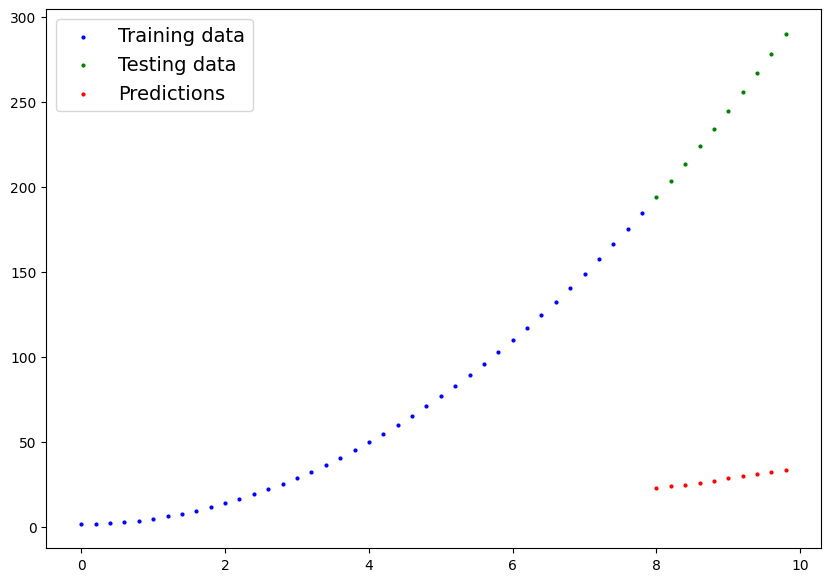

In [157]:
plot_predictions(predictions=y_preds)

Woah! Those predictions look pretty bad...

This makes sense though, when you remember our model is just using random parameter values to make predictions.

It hasn't even looked at the blue dots to try to predict the green dots.

Let's train to get better results. 

### Loss Function Selection

In [158]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### Model Training

In [159]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 50

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 


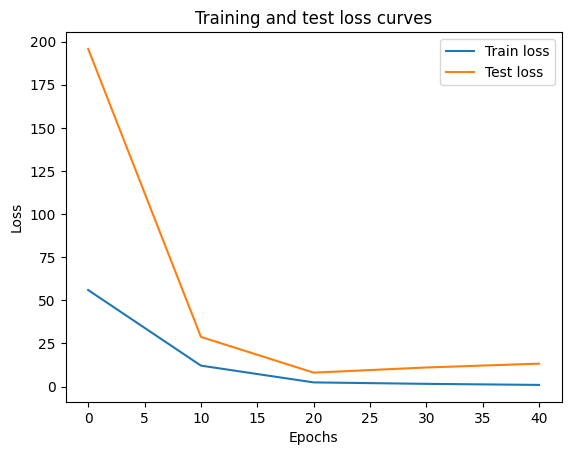

In [160]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [161]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weight_quad': tensor([2.9226]), 'weight_linear': tensor([0.6875]), 'bias': tensor([0.4515])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


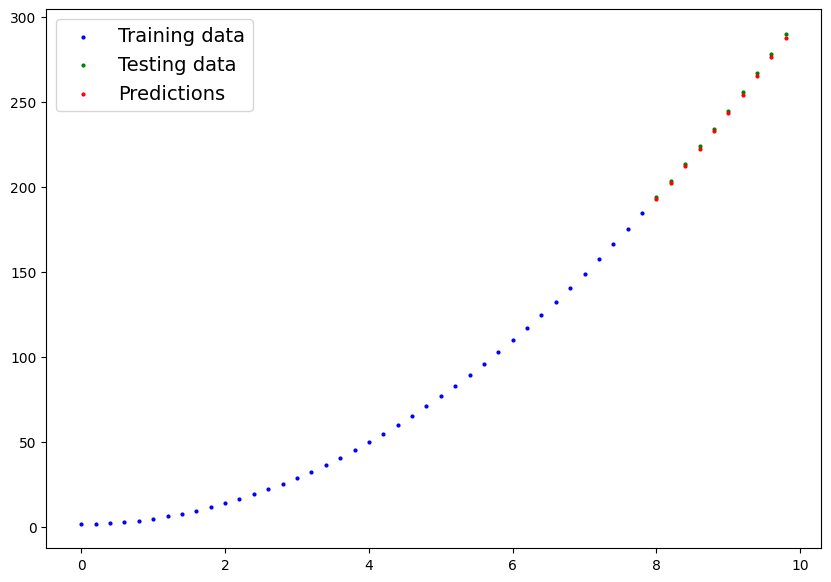

In [162]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Discussion

In this lab, a regression model was built using PyTorch to predict continuous values from input data. A simple feedforward neural network was used and trained using a loss function such as Mean Squared Error (MSE). The model parameters were updated using backpropagation and an optimizer like SGD or Adam.

During training, the loss gradually decreased, showing that the model was learning the relationship between inputs and outputs. The learning rate had a noticeable impact on performance, as too high a value made training unstable while too low slowed convergence. After training, the model was tested on unseen data to evaluate its performance.

The predicted values were close to the actual values in most cases, indicating that the model was able to capture the overall trend. However, slight differences between training and testing performance suggested a small amount of overfitting or the need for better tuning.

### Conclusion

This lab successfully demonstrated the implementation of a regression model using PyTorch. The neural network was able to learn the relationship between input features and continuous output values through training with backpropagation and an optimization algorithm such as SGD or Adam.

The results showed that the model effectively reduced prediction error over time, as seen from the decreasing loss values during training. This indicates that the network was able to learn meaningful patterns from the dataset. The comparison between predicted and actual values further confirmed that the model produced reasonably accurate outputs.

In [ ]:
import matplotlib.pyplot as plt

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")

plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

NameError: name 'epoch_count' is not defined